# Exercise 3: Health and disease

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Population and initial conditions
population = 137000  # Total population of New Haven
initial_infected = 1  # Initially infected individuals
initial_susceptible = population - initial_infected  # Initially susceptible individuals
initial_removed = 0  # Initially removed individuals
infection_rate = 2  # Beta, infection rate
recovery_rate = 1   # Gamma, recovery rate
total_days = 160    # Maximum simulation period in days

# Time step for Euler integration
time_step = 0.1


In [5]:
# Function to run SIR model simulation with Euler's method
def simulate_sir_explicit_euler(susceptible, infected, removed, beta, gamma, max_days, dt):
    time_points = np.arange(0, max_days, dt)
    S_values = np.zeros_like(time_points)
    I_values = np.zeros_like(time_points)
    R_values = np.zeros_like(time_points)

    # Initialize values
    S_values[0] = susceptible
    I_values[0] = infected
    R_values[0] = removed

    # Run Euler integration
    for k in range(1, len(time_points)):
        dS = -beta * S_values[k-1] * I_values[k-1] / population
        dI = beta * S_values[k-1] * I_values[k-1] / population - gamma * I_values[k-1]
        dR = gamma * I_values[k-1]

        S_values[k] = S_values[k-1] + dS * dt
        I_values[k] = I_values[k-1] + dI * dt
        R_values[k] = R_values[k-1] + dR * dt

        # Stop early if infections fall below 1
        if I_values[k] < 1:
            time_points = time_points[:k+1]
            S_values = S_values[:k+1]
            I_values = I_values[:k+1]
            R_values = R_values[:k+1]
            break

    return time_points, S_values, I_values, R_values


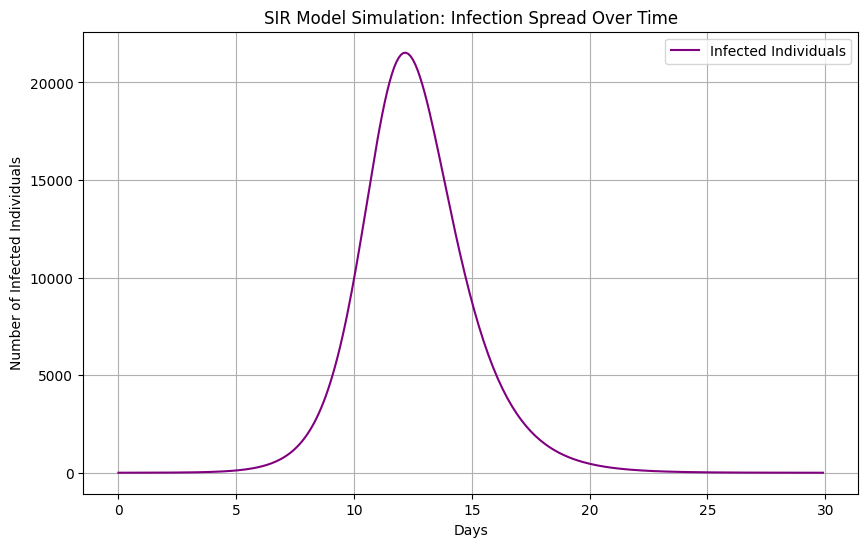

In [6]:
# Run the simulation
time, susceptible, infected, removed = simulate_sir_explicit_euler(
    initial_susceptible, initial_infected, initial_removed, infection_rate, recovery_rate, total_days, time_step
)

# Plot infected individuals over time
plt.figure(figsize=(10, 6))
plt.plot(time, infected, color='purple', label='Infected Individuals')
plt.xlabel('Days')
plt.ylabel('Number of Infected Individuals')
plt.title('SIR Model Simulation: Infection Spread Over Time')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# Identify peak infection day and peak count
max_infected = np.max(infected)
day_of_peak = time[np.argmax(infected)]
print(f"Peak Infection Day: {day_of_peak:.1f} days")
print(f"Peak Infection Count: {max_infected:.0f}")


Peak Infection Day: 12.2 days
Peak Infection Count: 21526


In [8]:
# Sensitivity analysis with beta and gamma variations
beta_range = np.linspace(1.8, 2.2, 20)  # Range for infection rate variations
gamma_range = np.linspace(0.9, 1.1, 20) # Range for recovery rate variations
time_to_peak_array = np.zeros((len(beta_range), len(gamma_range)))
peak_infection_array = np.zeros((len(beta_range), len(gamma_range)))

# Compute peak time and infection count for each beta-gamma pair
for i, beta_val in enumerate(beta_range):
    for j, gamma_val in enumerate(gamma_range):
        _, _, inf_values, _ = simulate_sir_explicit_euler(
            initial_susceptible, initial_infected, initial_removed, beta_val, gamma_val, total_days, time_step
        )
        time_to_peak_array[i, j] = time[np.argmax(inf_values)]
        peak_infection_array[i, j] = np.max(inf_values)


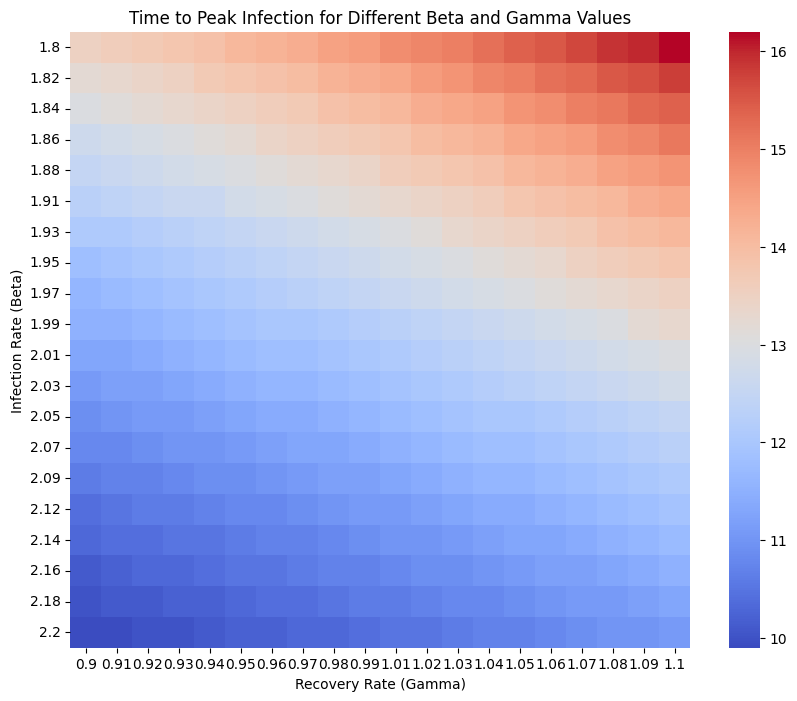

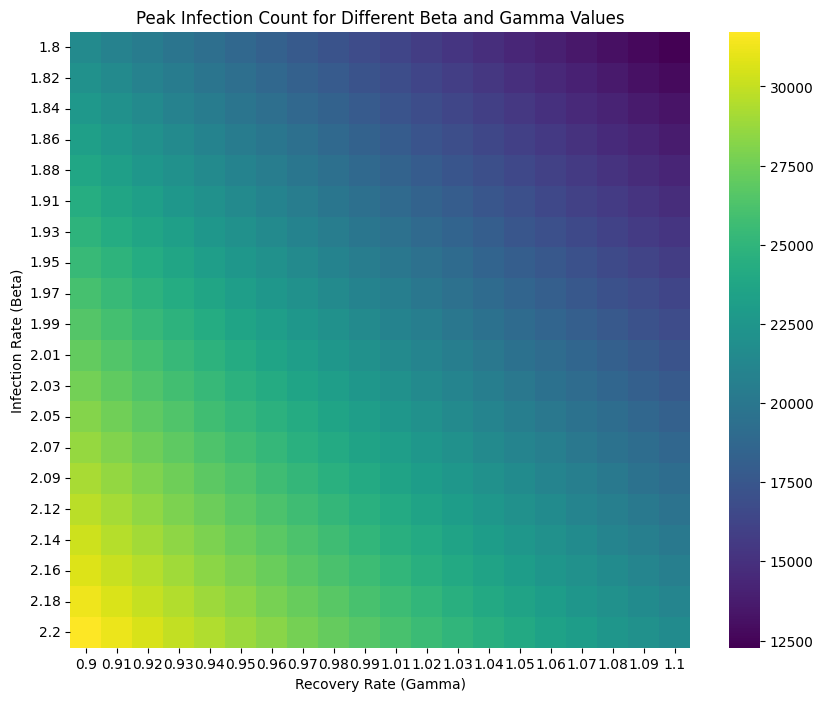

In [9]:
# Heatmap of time to peak infection based on beta and gamma
plt.figure(figsize=(10, 8))
sns.heatmap(time_to_peak_array, xticklabels=np.round(gamma_range, 2), yticklabels=np.round(beta_range, 2), cmap="coolwarm")
plt.xlabel('Recovery Rate (Gamma)')
plt.ylabel('Infection Rate (Beta)')
plt.title('Time to Peak Infection for Different Beta and Gamma Values')
plt.show()

# Heatmap of infection count at peak based on beta and gamma
plt.figure(figsize=(10, 8))
sns.heatmap(peak_infection_array, xticklabels=np.round(gamma_range, 2), yticklabels=np.round(beta_range, 2), cmap="viridis")
plt.xlabel('Recovery Rate (Gamma)')
plt.ylabel('Infection Rate (Beta)')
plt.title('Peak Infection Count for Different Beta and Gamma Values')
plt.show()


### Conclusion

In this analysis, we applied the SIR model to simulate a disease outbreak in New Haven, with a population of 137,000. Starting from an initial infection rate (\(\beta = 2\)) and recovery rate (\(\gamma = 1\)), with only 1 infected individual on day 0, the model predicted that infections would peak on **day 12.2** with **21,526** people infected. This peak represents the highest strain on healthcare resources before recovery rates begin to outweigh new infections.

To explore the effects of uncertain parameters, we conducted a sensitivity analysis on beta and gamma values. By varying these within a ±10% range, we found that higher infection rates caused a quicker and more severe peak, whereas higher recovery rates delayed and reduced peak infections. Heatmaps visualized these trends, highlighting how accurate parameter estimation is crucial for reliable outbreak projections.

Overall, this exercise demonstrated the importance of both parameter selection and sensitivity analysis in epidemiological modeling, allowing us to understand and predict disease dynamics in varying scenarios.